In [1]:
"""
exploration: write program that takes a 1d function on a finite interval [a, b], numerically integrates it (trapezoidal or simpson's rule, hand-rolled, no library), and reports whether its a valid pdf. 

test on three cases: 
  (1) uniform density: 1/(b-a)
  (2) unnormalized gaussian: exp(-x^2/2) without the 1/sqrt(2pi) factor, it should fail the integrates-to-1 test, compute what constant would fix it
  (3) function that dips negative somewhere, should fail the non-negativity test
"""

import math
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def _plot_function(f, a=-10, b=10, n=4096):
  xs = [a + (i * ((b - a) / n)) for i in range(n + 1)]
  ys = [f(x) for x in xs]
  plt.plot(xs, ys)
  plt.grid(True)
  plt.axhline(0, color='black', linewidth=0.8)
  plt.axvline(0, color='black', linewidth=0.8)
  plt.show()

In [3]:
def _simpson_integrate(f, a = -1024, b = 1024, n = 8192):
  result = 0
  for i in range(0, n - 1, 2):
    x0 = a + ((b - a) * (i / n))
    x1 = a + ((b - a) * ((i + 1) / n))
    x2 = a + ((b - a) * ((i + 2) / n))
    h = (b - a) / n
    cur_area = (h / 3) * ((f(x0) + (4 * f(x1)) + f(x2)))
    result += cur_area
  return result

In [4]:
def _make_gaussian(mean, stdev):
  def gaussian(x):
    return (1 / (stdev * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mean) / stdev) ** 2)
  return gaussian

In [5]:
def _make_linear(slope, y_intercept):
  def linear(x):
    return slope * x + y_intercept
  return linear

In [6]:
def _is_pdf(f, a = -1024, b = 1024):
  if (abs(_simpson_integrate(f, a, b) - 1) < 0.001):
    for i in np.arange(a, b + 1, 0.125):
      if f(i) < 0:
        return False
    return True
  return False

True


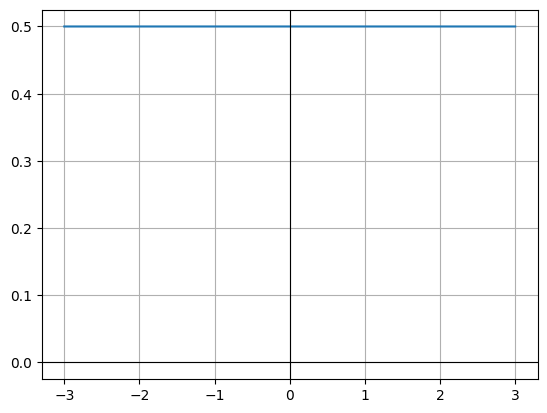

In [7]:
if __name__ == '__main__' and '__file__' not in globals():
  basic_linear = _make_linear(0, 0.5)
  print(_is_pdf(basic_linear, 0, 2))
  _plot_function(basic_linear, -3, 3)

1.0
True


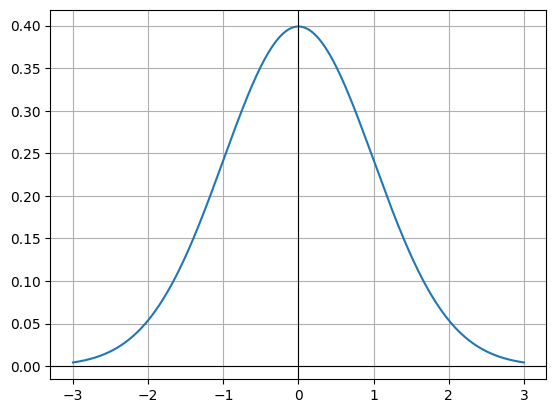

In [10]:
if __name__ == '__main__' and '__file__' not in globals():
  std_normal_dist = _make_gaussian(0.0, 1.0)
  print(_simpson_integrate(std_normal_dist))
  print(_is_pdf(std_normal_dist))
  _plot_function(std_normal_dist, -3, 3)